In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class PreprocessPipeline:
    def __init__(self, path="penguins.csv", one_hot_cols=None, label_encode_cols=None):
        # Initialize the values that would be needed in other funtions so we dont have to send the value again and again while calling the function
        self.path = path
        self.df = None
        self.scaled_df = None
        self.settings = {}
        self.one_hot_cols = one_hot_cols
        self.label_encode_cols = label_encode_cols

    def load_data(self):
      # Imported the dataset from csv
        self.df = pd.read_csv(self.path)
        #print(self.df.head(2))
        #print(self.df.shape)
        #print(self.df.dtypes)
        self.settings["loaded"] = f"Data loaded from {self.path} with shape {self.df.shape}"
        self.df.drop(columns=['GEO.id2.Id2'], inplace=True) #Dropping the unnamed column, as it didnt provide any significance to the output
        self.df.drop(columns=['GEO.display.label.Geography'], inplace=True) #Dropping the unnamed column, as it didnt provide any significance to the output
        return self.df

    def handle_missing(self):
      # Found the threshold and if the nan value is below it then drop that
        print('Before Null values : \n',self.df.isnull().sum())
        self.df = self.df.dropna(thresh=len(self.df.columns)//2)
        for col in self.df.select_dtypes(include=["object"]).columns:
            self.df[col] = self.df[col].fillna(self.df[col].mode()[0])
            #print('Missing values: \n',self.df)
        for col in self.df.select_dtypes(include=["int64","float64"]).columns:
            self.df[col] = self.df[col].fillna(self.df[col].median())
        print('After dropping Null values : \n',self.df.isnull().sum())
        self.settings["missing"] = "Dropped rows with >50% missing, filled categorical with mode, numeric with median"

    def clean_strings(self):
      # Made all the string in the dataset to lowercase
        for col in self.df.select_dtypes(include=["object"]).columns:
            self.df[col] = self.df[col].astype(str).str.strip().str.lower()
        self.settings["string_clean"] = "Stripped and lowercased strings"

    def handle_outliers(self):
      # Used IQR method to handel outliers
        for col in self.df.select_dtypes(include=["int64","float64"]).columns:
            Q1 = self.df[col].quantile(0.25)
            Q3 = self.df[col].quantile(0.75)
            IQR = Q3 - Q1
            lower, upper = Q1 - 1*IQR, Q3 + 1*IQR
            self.df[col] = np.where(self.df[col] < lower, self.df[col].mean(), self.df[col])
            self.df[col] = np.where(self.df[col] > upper, self.df[col].mean(), self.df[col])
        self.settings["outliers"] = "Outliers capped with mean using 1*IQR"

    def encode_categoricals(self):
      # Encoded by Onehot method for any column and if not given then by default for penguin dataset did for gender.
      #  if "gender" in self.df.columns:
      #     self.df["gender_encode"] = self.df["gender"].map({"male": 0, "female": 1})
        for col in self.one_hot_cols:
            if col in self.df.columns:
                encoded = pd.get_dummies(self.df[col], prefix=col, drop_first=True, dtype=int)
                self.df.drop(columns=[col], inplace=True)
                self.df = pd.concat([self.df, encoded], axis=1)
        #Added new condition to check if no label encoding is needed, we skip it or else we perform label encoding
        if self.label_encode_cols is None:
          pass
        else:
          for col in self.label_encode_cols:
              if col in self.df.columns:
                  self.df[col + "_encoded"] = self.df[col].astype("category").cat.codes
                  self.df.drop(columns=[col], inplace=True)
          self.settings["encoding"] = f"Label encoded: {self.label_encode_cols}, One-hot encoded: {self.one_hot_cols}"

    def to_numeric(self):
      # Made all the columns to numeric which are of object datatype
        for col in self.df.columns:
          if col in self.df.select_dtypes(include=["object"]).columns:
            self.df[col] = pd.to_numeric(self.df[col], errors='coerce')

        #print('Calling from function numeric: ',self.handle_missing())

    def scale_numeric(self):
        # Only scale numeric columns if they exist in the dataset
        num_cols = ["average us salary","number of diamonds mined (millions)","price","depth","table"]
        self.scaled_df = self.df.copy()
        existing_cols = [col for col in num_cols if col in self.scaled_df.columns]
        for col in existing_cols:
            min_val = self.scaled_df[col].min()
            max_val = self.scaled_df[col].max()
            self.scaled_df[col] = (self.scaled_df[col] - min_val) / (max_val - min_val)
        self.settings["scaling"] = {col:(self.scaled_df[col].min(), self.scaled_df[col].max()) for col in existing_cols}

    def visualizeData(self):
      # Visualize the dataset genericly
        numeric_df = self.scaled_df.select_dtypes(include=["float64","int64"])
        if numeric_df.shape[1] > 0:
          # Heat map for the values with respect to int and float 64
            plt.figure(figsize=(10,6))
            sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
            plt.title("Correlation Heatmap")
            plt.show()
           # Histogram map for the values with respect to int and float 64
            numeric_df.hist(figsize=(12,10))
            plt.suptitle("Histograms for Numeric Features", y=1.02)
            plt.show()
          # Box plot for the values with respect to int and float 64
            for col in numeric_df.columns[:3]:
                plt.figure(figsize=(6,4))
                sns.boxplot(x=numeric_df[col])
                plt.title(f"Boxplot of {col}")
                plt.show()
# pair plot for the values with respect to int and float 64
            if numeric_df.shape[1] >= 3:
                sns.pairplot(numeric_df.iloc[:, :3])
                plt.suptitle("Pairplot of 3 Numeric Features", y=1.02)
                plt.show()
# violin plot for the values with respect to int and float 64
            for col in numeric_df.columns[:3]:
                plt.figure(figsize=(6,4))
                sns.violinplot(x=numeric_df[col])
                plt.title(f"Violin Plot of {col}")
                plt.show()

        print("Settings Summary:\n", self.settings)


    def fit_transform(self):
      # Called all the function in one place
        self.load_data()
        self.handle_missing()
        self.clean_strings()
        self.handle_outliers()
        #self.encode_categoricals()
        self.to_numeric()
        self.handle_missing()
        self.handle_outliers()
        self.scale_numeric()
        #self.visualizeData()
        return self.scaled_df


In [10]:


Mypipeline = PreprocessPipeline(path="ACS_2017_Data_Profile_5_Year_Estimates,_Erie_County_-_Census_Tract_20251006.csv")
cleaned_df = Mypipeline.fit_transform()
print("\nCleaned dataset preview (first 5 rows):\n", cleaned_df.head(5))
print("\n Cleaned dataset datatype: \n", cleaned_df.dtypes)
print("Cleaned dataset shape:\n", cleaned_df.shape)
#Mypipeline.visualizeData()
cleaned_df.to_csv("ACS_2017_Data_Profile_5_Year_Estimates,_Erie_County_-_Census_Tract_20251006_preprocessed.csv", index=False)


Before Null values : 
 HC01_VC03.Estimate..HOUSEHOLDS.BY.TYPE...Total.households                                                                                                                 0
HC01_VC04.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families.                                                                                  0
HC01_VC05.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....With.own.children.of.the.householder.under.18.years                            0
HC01_VC06.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Married.couple.family                                                          0
HC01_VC07.Estimate..HOUSEHOLDS.BY.TYPE...Total.households...Family.households..families....Married.couple.family...With.own.children.of.the.householder.under.18.years    0
                                                                                                                     

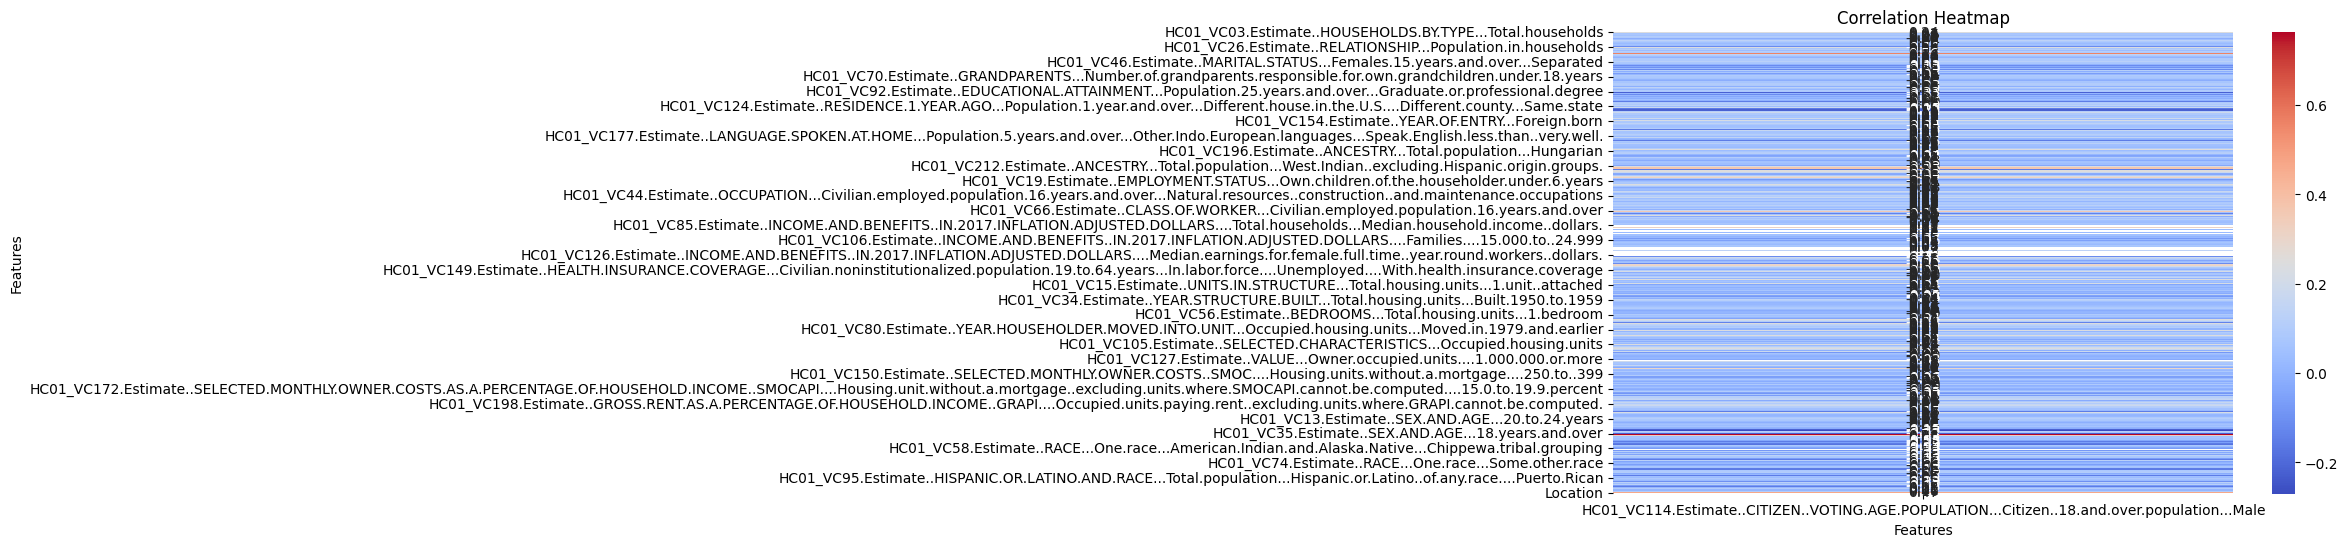

Set of features needed:  Index(['HC01_VC36.Estimate..MARITAL.STATUS...Males.15.years.and.over',
       'HC01_VC36.Estimate..SEX.AND.AGE...18.years.and.over...Male',
       'HC01_VC115.Estimate..CITIZEN..VOTING.AGE.POPULATION...Citizen..18.and.over.population...Female'],
      dtype='object')
(237, 4)


In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

corr_matrix = cleaned_df.corr()
target_corr = corr_matrix['HC01_VC114.Estimate..CITIZEN..VOTING.AGE.POPULATION...Citizen..18.and.over.population...Male'].drop('HC01_VC114.Estimate..CITIZEN..VOTING.AGE.POPULATION...Citizen..18.and.over.population...Male')
#print(target_corr)

plt.figure(figsize=(10,6))
sns.heatmap(target_corr.to_frame(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.xlabel("Features")
plt.ylabel("Features")
plt.show()


columnsNeeded = target_corr[(target_corr) >= 0.4].index
print('Set of features needed: ',columnsNeeded)
cleaned_df = cleaned_df[columnsNeeded.tolist() + ['HC01_VC114.Estimate..CITIZEN..VOTING.AGE.POPULATION...Citizen..18.and.over.population...Male']]

print(cleaned_df.shape)


In [12]:
np.random.seed(42)

#print('Values null there or not in the cleaned_df',cleaned_df.isnull().sum())
#Storing values with X column without the target variable
Y = cleaned_df["HC01_VC114.Estimate..CITIZEN..VOTING.AGE.POPULATION...Citizen..18.and.over.population...Male"]
X = cleaned_df.drop(columns=["HC01_VC114.Estimate..CITIZEN..VOTING.AGE.POPULATION...Citizen..18.and.over.population...Male"])

#print(Y.isnull().sum())
#print(X.isnull().sum())

rows = X.shape[0]
#print(rows)

print('Initial value of non target variable: \n',X.shape)
print('Initial value of target variable: \n',Y.shape)

indices = np.arange(rows)
np.random.shuffle(indices)
#print(indices)

split_size = int(0.8 * rows)

train_idx = indices[:split_size]
test_idx = indices[split_size:]

'''print(train_idx.shape)
print(test_idx.shape)'''

#Defining the model
X_train = X.iloc[train_idx]
y_train = Y.iloc[train_idx]
X_test = X.iloc[test_idx]
y_test = Y.iloc[test_idx]

print('Value of X train: ',X_train.shape)
print('Value of Y train: ',y_train.shape)
print('Value of X test shape: ',X_test.shape)
print('Value of Y test shape: ',y_test.shape)


Initial value of non target variable: 
 (237, 3)
Initial value of target variable: 
 (237,)
Value of X train:  (189, 3)
Value of Y train:  (189,)
Value of X test shape:  (48, 3)
Value of Y test shape:  (48,)


In [13]:
#To calculate the weights using OLS

#Before
print('Before X Type: \n',type(X_train))
print('Before Y Type: \n',type(y_train))
print('Before X shape: \n',X_train.shape)
print('Before Y shape: \n',y_train.shape)

#After
#Converting to numpy to perform operations
y_np = y_train.to_numpy().reshape(-1, 1)
X_np = X_train.to_numpy()
y_np_test = y_test.to_numpy().reshape(-1,1)
X_np_test = X_test.to_numpy()
print('After X Type: \n',type(X_np))
print('After X shape: \n',X_np.shape)
print('After Y Type: \n',type(y_np))
print('After Y shape: \n',y_np.shape)

#print('Null weights: ',X_train.isnull().sum())

#Transpose matrix
#print('Before Transpose matrix : \n',X_np)
#print('Transpose matrix : \n',X_np.T)


#Using linalg.inv to calculate the unverse of the matrix
weights = np.linalg.inv(X_np.T @ X_np) @ X_np.T @ y_np
print('Weights of the OLS method : \n',weights.shape)

#Making predictions
y_pred_train = X_np @ weights
print('Model prediction for training  data: \n',y_pred_train.shape)
y_pred_test = X_np_test @ weights
print('Model prediction for testing data : \n',y_pred_test.shape)

Before X Type: 
 <class 'pandas.core.frame.DataFrame'>
Before Y Type: 
 <class 'pandas.core.series.Series'>
Before X shape: 
 (189, 3)
Before Y shape: 
 (189,)
After X Type: 
 <class 'numpy.ndarray'>
After X shape: 
 (189, 3)
After Y Type: 
 <class 'numpy.ndarray'>
After Y shape: 
 (189, 1)
Weights of the OLS method : 
 (3, 1)
Model prediction for training  data: 
 (189, 1)
Model prediction for testing data : 
 (48, 1)


In [14]:
#Computing Mean squared error & coefficient of determination (R2)
mse_testval = np.mean((y_np_test-y_pred_test)**2)
print('Mean square error of Test data: \n',mse_testval)

mse_trainval = np.mean((y_np-y_pred_train)**2)
print('Mean square error of Train data: \n',mse_trainval)

#Calculating now the R2
#Training data set
residual_train = y_np - y_pred_train
squaredvaltrain = residual_train ** 2

squaredvaltrain = np.sum(squaredvaltrain)
#print('Sum of squared residuals train: \n',squaredvaltrain)

totalsumtrain = np.sum((y_np - np.mean(y_np))**2)
#print('Total sum of train: \n',totalsumtrain)

#Testing data set
residual_test = y_np_test - y_pred_test
squaredvaltest = residual_test ** 2

squaredvaltest = np.sum(squaredvaltest)
#print('Sum of squared residuals for test: \n',squaredvaltest)

totalsumtest = np.sum((y_np_test - np.mean(y_np_test))**2)
#print('Total sum of train: \n',totalsumtest)


#Calcualting R2
R2train = (1- squaredvaltrain/totalsumtrain)
print('R2 value for train data: \n',R2train)

R2test = (1- squaredvaltest/totalsumtest)
print('R2 value for test data: \n',R2test)


Mean square error of Test data: 
 25.693502255255694
Mean square error of Train data: 
 17.918680030473176
R2 value for train data: 
 0.6454107944085575
R2 value for test data: 
 0.5048285747640082


Values for the lambda passed 1e-05
Model prediction for training  data: (189, 1)
Model prediction for testing data : (48, 1)
Training loss:  8.959343436086183
TestLoss:  12.846754555380949
Mean square error of Train data:  17.918680030473062
Mean square error of Test data:  25.693502269062595
R2 value for train data:  0.6454107944085598
R2 value for test data:  0.5048285744979182


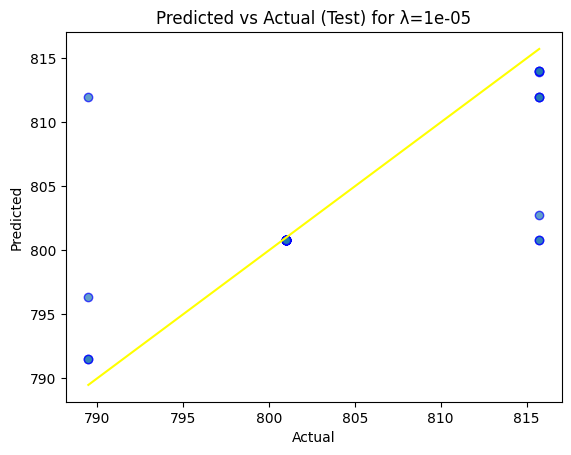

-------------------------------------------------------------
Values for the lambda passed 0.1
Model prediction for training  data: (189, 1)
Model prediction for testing data : (48, 1)
Training loss:  8.993546665702034
TestLoss:  12.88102043263271
Mean square error of Train data:  17.918680040267112
Mean square error of Test data:  25.69362757412846
R2 value for train data:  0.6454107942147473
R2 value for test data:  0.5048261595882093


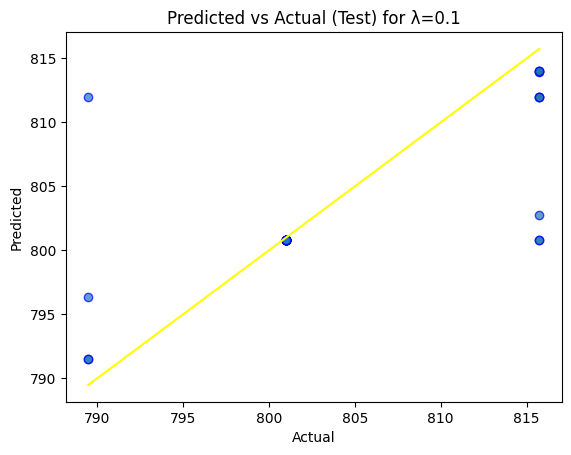

-------------------------------------------------------------
Values for the lambda passed 1
Model prediction for training  data: (189, 1)
Model prediction for testing data : (48, 1)
Training loss:  9.301240498927129
TestLoss:  13.189277785076719
Mean square error of Train data:  17.91868100888861
Mean square error of Test data:  25.694755581187792
R2 value for train data:  0.6454107750468885
R2 value for test data:  0.5048044203617816


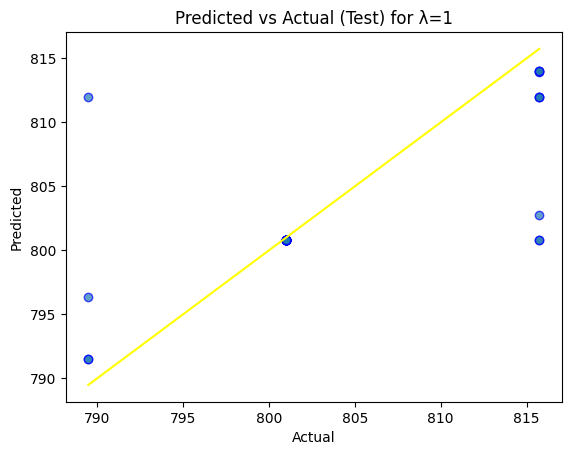

-------------------------------------------------------------
Values for the lambda passed 10
Model prediction for training  data: (189, 1)
Model prediction for testing data : (48, 1)
Training loss:  12.361880195614882
TestLoss:  16.255511015181963
Mean square error of Train data:  17.918776890120174
Mean square error of Test data:  25.706038529254332
R2 value for train data:  0.6454088776722118
R2 value for test data:  0.5045869726421415


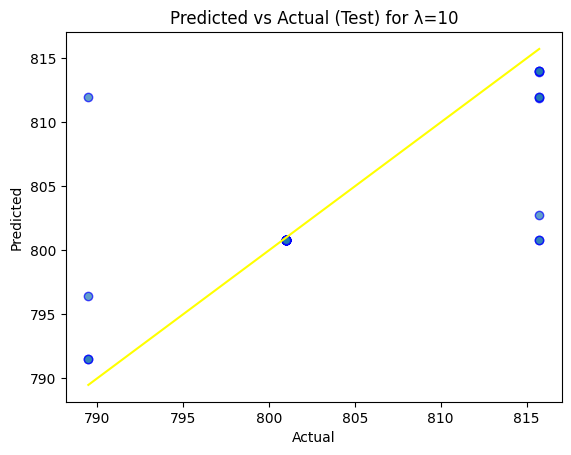

-------------------------------------------------------------


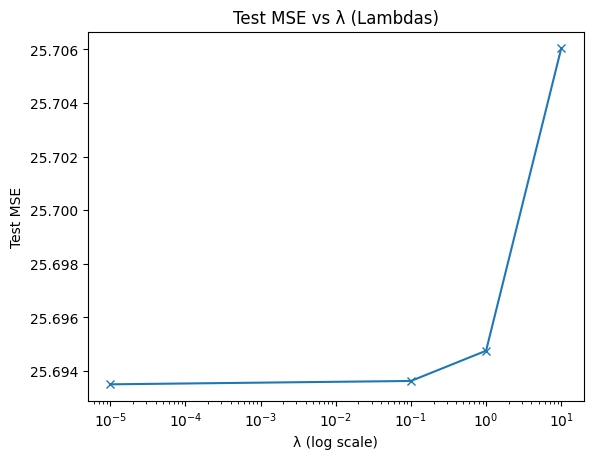

Index val:  0
Optimal weights 
 [[0.0054936 ]
 [0.80083033]
 [0.20690705]]
Best λ: 1e-05
Test MSE (optimal): 25.693502269062595
Test R² (optimal ): 0.5048285744979182
Weights shape: (3, 1)


In [15]:
#Calculating ridge regression using OLS

def mean_squared_error(Y,Y_pred):
  return np.mean((Y-Y_pred)**2)

def residual_sum_of_squares(Y,Y_pred):
  residual_train = Y - Y_pred
  squaredvaltrain = residual_train ** 2

  squaredvaltrain = np.sum(squaredvaltrain)
  #print('Sum of squared residuals train: \n',squaredvaltrain)

  totalsumtrain = np.sum((Y - np.mean(Y))**2)
  #print('Total sum of train: \n',totalsumtrain)

  R2train = (1- squaredvaltrain/totalsumtrain)
  return R2train
#Creating the ridge loss function to compute the los
def ridgeLoss(X,y,w,lam):
  N = X.shape[0]
  #print(N)
  y_pred = X @ w
  difference = y-y_pred
  l2_loss = (1 / (2 * N)) * np.sum(difference ** 2)
  reg_term = 0.5 * lam * (w.T @ w)
  total_loss = l2_loss + reg_term
  return total_loss.item()

#Changing/calculating weights
def calculate_ridge_weights(X, y, lam):
  I = np.eye(X.shape[1])
  w = np.linalg.inv(X.T @ X + lam * I) @ X.T @ y
  return w

lambdasval = [0.00001, 0.1, 1, 10]
weightlist = []
trainList = []
testList = []
trainMSEList = []
testMSEList = []
R2trainList = []
R2testList = []


for lam in lambdasval:
  weight = calculate_ridge_weights(X_np,y_np,lam)
  weightlist.append(weight)

  trainLoss = ridgeLoss(X_np,y_np,weight,lam)
  testLoss = ridgeLoss(X_np_test,y_np_test,weight,lam)
  trainList.append(trainLoss)
  testList.append(testLoss)

  #Model predictions
  y_pred_train = X_np @ weight
  y_pred_test = X_np_test @ weight


  print(f'Values for the lambda passed {lam}')
  print(f'Model prediction for training  data: {y_pred_train.shape}')
  print('Model prediction for testing data :' ,y_pred_test.shape)
  print('Training loss: ',trainLoss)
  print('TestLoss: ',testLoss)


  #Now to calculate the MSE and R2
  mse_trainval = mean_squared_error(y_np,y_pred_train)
  print('Mean square error of Train data: ',mse_trainval)
  trainMSEList.append(mse_trainval)
  mse_testval = mean_squared_error(y_np_test,y_pred_test)
  print('Mean square error of Test data: ',mse_testval)
  testMSEList.append(mse_testval)

  #Calculating now the R2
  #Training data set
  r2Trainval = residual_sum_of_squares(y_np,y_pred_train)
  print('R2 value for train data: ',r2Trainval)
  R2trainList.append(r2Trainval)

  #Testing data set
  r2Testval = residual_sum_of_squares(y_np_test,y_pred_test)
  print('R2 value for test data: ',r2Testval)
  R2testList.append(r2Testval)

  plt.figure()
  plt.scatter(y_test, y_pred_test, alpha=0.7, edgecolors='blue')
  plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='yellow')
  plt.title(f'Predicted vs Actual (Test) for λ={lam}')
  plt.xlabel('Actual')
  plt.ylabel('Predicted')
  plt.show()
  print('-------------------------------------------------------------')

plt.figure()
plt.plot(lambdasval, testMSEList, marker='x')
plt.xscale('log')
plt.title('Test MSE vs λ (Lambdas)')
plt.xlabel('λ (log scale)')
plt.ylabel('Test MSE')
plt.show()

#Calculating the Best Mse and R2 wrt the weights used
indexVal = np.argmin(testMSEList)
print('Index val: ',indexVal)
lambdaBest = lambdasval[indexVal]
#print('Lambda val: ',lambdaBest)
optimalweight = weightlist[indexVal]
print('Optimal weights \n',optimalweight)

print(f'Best λ: {lambdaBest}')
print(f'Test MSE (optimal): {testMSEList[indexVal]}')
print(f'Test R² (optimal ): {R2testList[indexVal]}')
print(f'Weights shape: {optimalweight.shape}')




In [17]:
import pickle

with open("a1_bonus_weights_rajagop6_raviraja.pkl", "wb") as f:
    pickle.dump(optimalweight, f)

One of the major reason , i could see that for test data the predictions has been poor is because of overfitting , i have considered strongly coorelated features with respect to my target column and hence initally i had around 750 total columns and then after i applied encoding and found the correlation matrix , Kept only those that are greater than 0.4 . However the results are not optimal . I tried using the ridge expression with differnet values of lambda but yet the performance has not increased much. Another possible reason i can consider is since i have used very strong features, only limited featuers/columns are being used and can be possibly one reason why ridge expression has not been improving


#### **References**
https://numpy.org/devdocs/reference/generated/numpy.linalg.inv.html

https://www.geeksforgeeks.org/machine-learning/ordinary-least-squares-ols/

https://peps.python.org/pep-0465/